In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

Load Dataset

In [138]:
dataset = pd.read_csv('mushroom.csv')

Tampilkan 5 baris pertama

In [143]:
print(dataset.head())

   class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0      1         x           s         n       t    p               f   
1      0         x           s         y       t    a               f   
2      0         b           s         w       t    l               f   
3      1         x           y         w       t    p               f   
4      0         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1 

Ganti nama kolom

In [139]:
dataset.columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape",
    "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color", "population", "habitat"
]

Encoding kolom target

In [142]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [141]:
label_encoder = LabelEncoder()
dataset['class'] = label_encoder.fit_transform(dataset['class'])

Cek data duplikat dan nilai kosong

In [144]:
# Cek data duplikat
print("Jumlah data duplikat:", dataset.duplicated().sum())
dataset = dataset.drop_duplicates()

# Cek nilai kosong
print("Jumlah nilai kosong di setiap kolom:")
print(dataset.isnull().sum())

Jumlah data duplikat: 0
Jumlah nilai kosong di setiap kolom:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


One-Hot Encoding untuk fitur kategori

In [145]:
features = dataset.drop('class', axis=1)
target = dataset['class']
encoded_features = pd.get_dummies(features)

Gabungkan fitur dengan target

In [146]:
processed_dataset = pd.concat([encoded_features, target], axis=1)

Split dataset

In [147]:
X = processed_dataset.drop('class', axis=1)
y = processed_dataset['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Periksa distribusi kelas di data latih dan uji

In [148]:
print("\nDistribusi kelas di data latih:")
print(y_train.value_counts())
print("\nDistribusi kelas di data uji:")
print(y_test.value_counts())


Distribusi kelas di data latih:
class
0    3365
1    3134
Name: count, dtype: int64

Distribusi kelas di data uji:
class
0    843
1    782
Name: count, dtype: int64


Periksa beberapa contoh data latih dan uji

In [149]:
print("\nContoh data latih (X_train) pertama 5 baris:")
print(X_train.head())
print("\nContoh target latih (y_train) pertama 5 nilai:")
print(y_train.head())


Contoh data latih (X_train) pertama 5 baris:
      cap-shape_b  cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  \
7873        False        False        False         True        False   
6515        False        False        False        False        False   
6141        False        False         True        False        False   
2764        False        False         True        False        False   
438          True        False        False        False        False   

      cap-shape_x  cap-surface_f  cap-surface_g  cap-surface_s  cap-surface_y  \
7873        False          False          False           True          False   
6515         True          False          False           True          False   
6141        False          False          False          False           True   
2764        False           True          False          False          False   
438         False          False          False          False           True   

      ...  population_s  pop

Standarisasi fitur

In [150]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Coba model Logistic Regression untuk diagnosis

In [151]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

Evaluasi model Logistic Regression

In [152]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"\nModel Logistic Regression - Akurasi: {accuracy_lr:.2f}, Precision: {precision_lr:.2f}, Recall: {recall_lr:.2f}, F1-Score: {f1_lr:.2f}")


Model Logistic Regression - Akurasi: 1.00, Precision: 1.00, Recall: 1.00, F1-Score: 1.00


Confusion Matrix untuk Logistic Regression

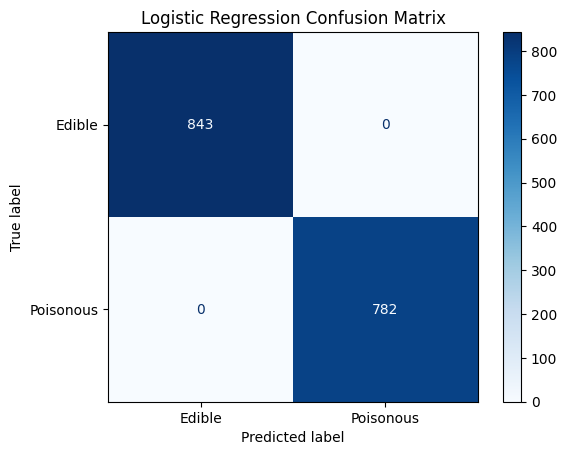

In [153]:
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_lr, display_labels=['Edible', 'Poisonous'])
disp_lr.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()